<a href="https://colab.research.google.com/github/QasimNiazi86/TransferLearning/blob/main/Tutorial7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cuda
Loading CIFAR-10 Dataset... [cite: 1163-1166]


100%|██████████| 170M/170M [00:14<00:00, 12.0MB/s]



--- Setting up ResNet50 for Feature Extraction ---
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 244MB/s]


--- Setting up VGG16 for Fine-Tuning ---
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 228MB/s]



Training ResNet50 (Feature Extraction)...
Epoch 1/5 | Val Loss: 1.2138 | Val Acc: 0.6458
Epoch 2/5 | Val Loss: 0.9519 | Val Acc: 0.7292
Epoch 3/5 | Val Loss: 0.9041 | Val Acc: 0.6949
Epoch 4/5 | Val Loss: 0.8543 | Val Acc: 0.7381
Epoch 5/5 | Val Loss: 0.8418 | Val Acc: 0.7217

Training VGG16 (Fine-Tuning)...
Epoch 1/5 | Val Loss: 1.7349 | Val Acc: 0.5818
Epoch 2/5 | Val Loss: 0.8791 | Val Acc: 0.7321
Epoch 3/5 | Val Loss: 0.6952 | Val Acc: 0.7708
Epoch 4/5 | Val Loss: 0.5942 | Val Acc: 0.8095
Epoch 5/5 | Val Loss: 0.5459 | Val Acc: 0.8214

=== Final Comparison ===
ResNet50 Feature Extraction Accuracy: 72.17%
VGG16 Fine-Tuning Accuracy:         82.14%


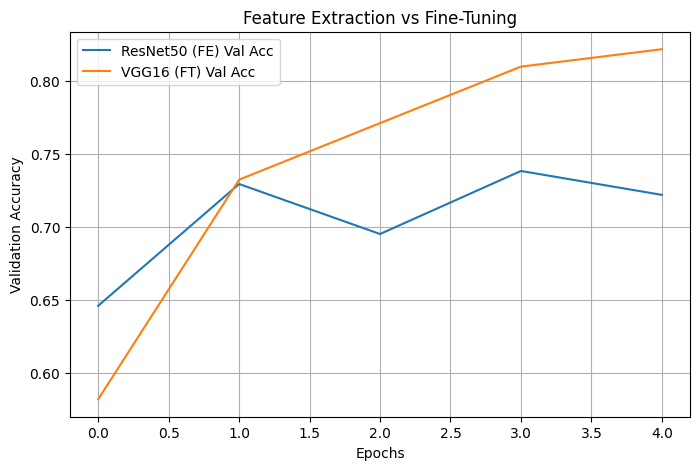

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# Step 1 & 2: Load and Preprocess the Dataset
# ==========================================
# Preprocessing formatting[cite: 1215]: Using ImageNet normalization means/stds
# is highly recommended when using pre-trained ImageNet weights.
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Upscaling 32x32 CIFAR to 224x224 for better pre-trained feature extraction
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Loading CIFAR-10 Dataset... [cite: 1163-1166]")
trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
testloader = DataLoader(testset, batch_size=32, shuffle=False)

num_classes = 10

# ==========================================
# Task: Feature Extraction with ResNet50 [cite: 1221, 1223]
# ==========================================
print("\n--- Setting up ResNet50 for Feature Extraction ---")
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all layers [cite: 1169-1173]
for param in resnet50.parameters():
    param.requires_grad = False

# Replace the final classification layer (requires_grad is True by default for new layers)
num_ftrs = resnet50.fc.in_features
resnet50.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.5), # Task: Prevent overfitting [cite: 1213]
    nn.Linear(512, num_classes)
)
resnet50 = resnet50.to(device)

# Optimizer ONLY updates the new 'fc' parameters [cite: 1181-1182]
optimizer_fe = optim.Adam(resnet50.fc.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# ==========================================
# Task: Fine-Tuning with VGG16 [cite: 1223]
# ==========================================
print("--- Setting up VGG16 for Fine-Tuning ---")
vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# Freeze all layers initially
for param in vgg16.parameters():
    param.requires_grad = False

# Task: Unfreeze the last few convolutional layers (Block 5) [cite: 1218]
for param in vgg16.features[24:].parameters():
    param.requires_grad = True

# Replace the classifier
num_ftrs_vgg = vgg16.classifier[0].in_features
vgg16.classifier = nn.Sequential(
    nn.Linear(num_ftrs_vgg, 512),
    nn.ReLU(),
    nn.Dropout(0.5), # Task: Prevent overfitting [cite: 1213]
    nn.Linear(512, num_classes)
)
vgg16 = vgg16.to(device)

# Optimizer updates the unfreezed conv layers AND the new classifier
# Task: Changing learning rate - Use a very small LR for fine-tuning pre-trained weights [cite: 1212]
optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, vgg16.parameters()), lr=1e-5)

# ==========================================
# Reusable Training Loop with Early Stopping [cite: 1214]
# ==========================================
def train_model(model, optimizer, model_name, epochs=10, patience=3):
    print(f"\nTraining {model_name}...")
    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        # We'll use a subset of batches for speed in this tutorial script.
        # Remove the break condition in a real scenario.
        for i, (inputs, targets) in enumerate(trainloader):
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

            if i == 50: # Limit to 50 batches for faster tutorial demonstration
                break

        train_acc = correct / total

        # Validation
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for i, (inputs, targets) in enumerate(testloader):
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += targets.size(0)
                correct += (predicted == targets).sum().item()

                if i == 20: # Limit validation batches for speed
                    break

        val_loss /= 20
        val_acc = correct / total
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # Early Stopping Logic [cite: 1214]
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered for {model_name}!")
                break

    return history, val_acc

# ==========================================
# Train & Evaluate Both Models [cite: 1201-1207]
# ==========================================
# Note: For tutorial speed, epochs are set to 5. Increase for actual training.
history_fe, acc_fe = train_model(resnet50, optimizer_fe, "ResNet50 (Feature Extraction)", epochs=5)
history_ft, acc_ft = train_model(vgg16, optimizer_ft, "VGG16 (Fine-Tuning)", epochs=5)

# ==========================================
# Compare Results [cite: 1205-1207]
# ==========================================
print("\n=== Final Comparison ===")
print(f"ResNet50 Feature Extraction Accuracy: {acc_fe * 100:.2f}%")
print(f"VGG16 Fine-Tuning Accuracy:         {acc_ft * 100:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(history_fe['val_acc'], label='ResNet50 (FE) Val Acc')
plt.plot(history_ft['val_acc'], label='VGG16 (FT) Val Acc')
plt.title('Feature Extraction vs Fine-Tuning')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()